# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_squared_error, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import shap
# Import your chosen baseline model
from sklearn.ensemble import RandomForestClassifier

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]

A Random Forest is well suited as a baseline for this dataset because it handles high-dimensional, non-linear features effectively and requires minimal preprocessing of the biovolume bins. It is robust to noise, correlations, and class imbalance, and it provides interpretable feature importances. This makes it a strong, reliable reference model before exploring more complex approaches.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]

Including:
For the baseline model, all biovolume-normalized bin features (approximately 680 columns covering ESD ranges from 0.203–0.256 mm up to 8.19–10.3 mm) are used. These variables capture the full size-spectrum distribution of the plankton community and represent the core ecological signal of each profile.

Excluding:
Profile_id, because it is an identifier and provides no predictive ecological information.
cluster, because it is the target label.

This selection yields a clean baseline that leverages only meaningful biological measurements, avoids information leakage, and provides a robust point of comparison for future feature engineering.


In [2]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
df_bioVol = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')
#df_clusters = pd.read_pickle('../Data/Profile_id_to_clusters.pkl')
df_clusters = pd.read_pickle('../Data/Profile_id_to_clusters_per_variable.pkl')
#df.info()
df_clusters.info()

# Transform the dataset into one big array
df_merged = df_bioVol.merge(df_clusters[['Profile_id', 'cluster']], 
                           on='Profile_id', 
                           how='left')
#df_merged.info()
df_merged.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Profile_id  5619 non-null   object
 1   cluster     5619 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 66.0+ KB


,Profile_id,depth,depth_bin,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm),Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm),Biovolume norm [ppm mm-1] (ESD: 0.323-0.406 mm),Biovolume norm [ppm mm-1] (ESD: 0.406-0.512 mm),Biovolume norm [ppm mm-1] (ESD: 0.512-0.645 mm),Biovolume norm [ppm mm-1] (ESD: 0.645-0.813 mm),Biovolume norm [ppm mm-1] (ESD: 0.813-1.02 mm),...,Biovolume norm [ppm mm-1] (ESD: 1.29-1.63 mm),Biovolume norm [ppm mm-1] (ESD: 1.63-2.05 mm),Biovolume norm [ppm mm-1] (ESD: 2.05-2.58 mm),Biovolume norm [ppm mm-1] (ESD: 2.58-3.25 mm),Biovolume norm [ppm mm-1] (ESD: 3.25-4.1 mm),Biovolume norm [ppm mm-1] (ESD: 4.1-5.16 mm),Biovolume norm [ppm mm-1] (ESD: 5.16-6.5 mm),Biovolume norm [ppm mm-1] (ESD: 6.5-8.19 mm),Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm),cluster
0,0000a_WMO5906623_recovery_profiles,12.5,0,2.161550,1.554601,0.949156,0.623950,0.614943,0.373631,0.593746,...,0.057567,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0000a_WMO5906623_recovery_profiles,37.5,1,2.580195,1.753025,1.373398,1.105171,1.070264,0.706832,0.558432,...,0.418343,0.113257,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0000a_WMO5906623_recovery_profiles,62.5,2,2.400416,1.772242,1.623328,1.479122,1.334517,0.869980,0.701836,...,0.072918,0.000000,0.373121,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0000a_WMO5906623_recovery_profiles,87.5,3,3.306409,2.497702,2.840614,2.380222,2.181843,1.829034,1.323362,...,0.730359,0.342512,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0000a_WMO5906623_recovery_profiles,112.5,4,2.394776,2.351693,2.481769,2.482301,2.846224,3.045748,2.522842,...,1.407133,1.418357,0.462381,0.0,0.0,0.0,0.0,0.0,0.0,1


In [3]:
# Transform the dataset, so that we have one row per profile_id. depth and Biovolume data are merged into columns with Biovolume_1_depth_1 etc
# 1. Biovolumen-Spalten identifizieren
biovol_cols = [c for c in df_bioVol.columns 
               if c.startswith("Biovolume norm")]

# 2. Pivotieren: jede Profile_id -> eine Zeile
df_pivot = df_bioVol.pivot_table(
    index="Profile_id",
    columns="depth_bin",
    values=biovol_cols
)

# 3. Spalten umbenennen zu flachen Namen
df_pivot.columns = [
    f"{col[0]}_bin{col[1]}"
    for col in df_pivot.columns.to_flat_index()
]

df_pivot = df_pivot.reset_index()
df_final = df_pivot.merge(df_clusters, on="Profile_id", how="left")
df_final.head()

,Profile_id,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin0,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin1,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin2,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin3,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin4,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin5,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin6,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin7,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin8,...,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin31,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin32,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin33,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin34,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin35,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin36,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin37,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin38,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin39,cluster
0,0000a_WMO5906623_recovery_profiles,2.161550,2.580195,2.400416,3.306409,2.394776,1.255357,0.604996,0.589779,0.576371,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0002a_WMO5906623_recovery_profiles,3.208806,3.237325,3.404851,3.816939,2.478618,0.885300,0.633760,0.695223,0.649789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0003a_WMO5906623_recovery_profiles,4.888812,3.739590,3.636295,3.837647,2.616829,1.138090,0.802445,0.695261,0.743481,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0003a_WMO6904139_recovery,0.955578,0.823861,0.613725,0.713172,0.530409,0.473657,0.575658,0.528344,0.575982,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0004a_WMO6903096,1.878435,1.645167,0.595265,0.433628,0.340781,0.349608,0.275279,0.289115,0.292104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [4]:
# Feature selection
# Example: Selecting only two features for a simple baseline model
# select columns as features
biovol_cols = [c for c in df_final.columns 
               if c.startswith("Biovolume norm")]

X = df_final[biovol_cols]
y = df_final['cluster']

# Splitting the dataset

#1.Option : without stratify
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2.Option : with stratify
# Over and under sampling of data, each cluster in training set!

# Train/Test-Split (optional: stratify, to have each cluster in training set)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # empfehlenswert bei Klassenungleichgewicht
)

# -----------------------------------------
# Balancing: jedes Cluster genau 600-mal im Trainingssatz
# -----------------------------------------

train_df = X_train.copy()
train_df["cluster"] = y_train.values

target_n = 600  # gewünschte Anzahl pro Cluster
balanced_groups = []

for label, group in train_df.groupby("cluster"):
    if len(group) > target_n:
        # Zu viele Samples → auf 600 reduzieren
        sampled = group.sample(n=target_n, random_state=42)
    elif len(group) < target_n:
        # Zu wenige Samples → mit Zurücklegen auf 600 auffüllen
        sampled = group.sample(n=target_n, replace=True, random_state=42)
    else:
        sampled = group
    balanced_groups.append(sampled)

balanced_df = pd.concat(balanced_groups)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_df.drop(columns="cluster")
y_train_balanced = balanced_df["cluster"]

print("distribution before:")
print(y_train.value_counts())
print("\ndistribution after:")
print(y_train_balanced.value_counts())

# -----------------------------------------
# Ab hier nimmst du für das Modell:
# X_train_balanced, y_train_balanced
# und zum Testen weiterhin: X_test, y_test
# -----------------------------------------
#############


distribution before:
cluster
1    849
7    830
6    555
2    554
4    526
0    352
5    326
9    220
8    198
3     85
Name: count, dtype: int64

distribution after:
cluster
2    600
6    600
0    600
3    600
8    600
1    600
4    600
5    600
9    600
7    600
Name: count, dtype: int64


## Implementation

[Implement your baseline model here.]



In [5]:
# Initialize and train the baseline model

# Your implementation code here

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"  
)


# Modell auf balancierten Trainingsdaten trainieren
rf.fit(X_train_balanced, y_train_balanced)


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Auf dem (unveränderten) Testset vorhersagen
y_pred = rf.predict(X_test)

#print("Accuracy:", accuracy_score(y_test, y_pred))
#print(classification_report(y_test, y_pred))

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]

To assess the baseline model’s performance and establish reference values for more complex models later on, following metrics are used:

# Accuracy

Measures the overall proportion of correct predictions. Useful for a general performance overview, but limited when class imbalance is present. 

# Balanced Accuracy

Computes the average recall across all classes, giving equal weight to minority and majority classes.
This metric is essential because the cluster distribution is imbalanced.

# Macro F1 Score

Averages the F1-score across all classes without weighting by class frequency.
This provides a balanced view of precision and recall for each cluster, including minority groups.

# Confusion Matrix

Visualizes how often each cluster is correctly and incorrectly classified.
Helps detect systematic misclassification patterns between clusters.

# Classification Report

Summarizes precision, recall, and F1-score for each class individually.
Supports detailed assessment of classes that are harder to separate.

# SHAP (SHapley Additive exPlanations)

Provides model-agnostic feature-attribution scores that show how much each feature contributes to a prediction.
SHAP will be used to:

interpret global feature importance,

analyze feature effects for each cluster,

understand why certain samples are misclassified.

## Results

# 1. Train–Test Comparison: Clear Overfitting

The Random Forest achieves:

Training Accuracy / Balanced Accuracy / Macro F1 ≈ 1.00

Test Accuracy = 0.71

Test Balanced Accuracy = 0.66

Test Macro F1 = 0.68

Interpretation:
The model has learned the training data almost perfectly but generalizes much worse to unseen data.
This is a classic case of overfitting, driven by:

very high feature dimensionality (680 features),

oversampling to exactly 600 samples per class,

deep, highly flexible decision trees.

This is expected in early baselines and provides a meaningful reference point for later improvements.

# 2.  Class-Level Performance Patterns
Well-predicted clusters (F1 ≥ 0.75):

Clusters 1, 5, 7, 9

These clusters have distinct biovolume distributions that the model can identify reliably.

Moderately predicted clusters (F1 ≈ 0.60–0.70):

Clusters 0, 4, 6, 8

These clusters show partial overlap with others.

Difficult clusters:

Cluster 2: Recall only 0.51 → many missed

Cluster 3: Recall only 0.33 → small class with strong overlap

Cluster 8: Recall 0.52 → partly confused with 7

Interpretation:
Certain clusters occupy overlapping ecological or feature-space regions, making them harder to separate using biovolume size spectra alone.

# 3. Confusion Matrix Interpretation

Key misclassification patterns:

Cluster 2 → {6, 7}

Cluster 3 → {1, 5}

Cluster 4 → 0

Cluster 8 → 7

These patterns suggest:

shared biovolume structure among specific cluster pairs,

insufficient discriminative information in the raw biovolume bins for certain classes,

potential benefits from dimensionality reduction or engineered features.

# 4. Feature Importance Interpretation (Random Forest)

Top features are dominated by Biovolume norm (ESD: 0.256–0.323 mm) across many bins (27–39).

Additional contributors include:

(ESD: 1.02–1.29 mm)_bin0

(ESD: 1.29–1.63 mm)_bin0

(ESD: 0.813–1.02 mm)_bin0

(ESD: 1.63–2.05 mm)_bin0

Interpretation:

Small particle sizes (0.256–0.323 mm) carry the strongest ecological signal for distinguishing clusters.

The model relies on fine-scale variation within a narrow ESD band.

This suggests that cluster identity is governed primarily by microplankton or small particle distributions, rather than large organisms.

The importance values are low and evenly distributed, indicating that the model depends on many weak signals, increasing overfitting risk.


# 5. Interpretation of Global SHAP Feature Importances

The SHAP results show that two groups of features drive the model’s predictions:

Medium-sized particles (0.6–2.05 mm, bin0 values)
Several bin0 features from larger ESD ranges appear at the top.
This indicates that the initial concentration level of medium particles provides strong information for distinguishing clusters.

Small particles (0.256–0.323 mm)
Many bins from this ESD range also rank highly.
This confirms that fine-scale variation in the small-particle spectrum is a key driver of cluster identity.

Compared to Random Forest importance, SHAP shows a more balanced picture:
both medium-sized particle bin0 features and small-particle bins contribute substantially.

Overall, the model relies on distributed signals across the size spectrum rather than a single dominant feature group.



=== Train Metrics ===
Accuracy:           0.9998333333333334
Balanced Accuracy:  0.9998333333333334
Macro F1:           0.9998333332175925

=== Test Metrics ===
Accuracy:           0.7135231316725978
Balanced Accuracy:  0.6598459615858562
Macro F1:           0.6793909286905958

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.61      0.62      0.62        88
           1       0.78      0.84      0.81       213
           2       0.71      0.51      0.60       138
           3       0.88      0.33      0.48        21
           4       0.66      0.66      0.66       131
           5       0.72      0.78      0.75        81
           6       0.68      0.72      0.70       139
           7       0.70      0.82      0.76       208
           8       0.76      0.52      0.62        50
           9       0.83      0.78      0.80        55

    accuracy                           0.71      1124
   macro avg       0.73      0.66

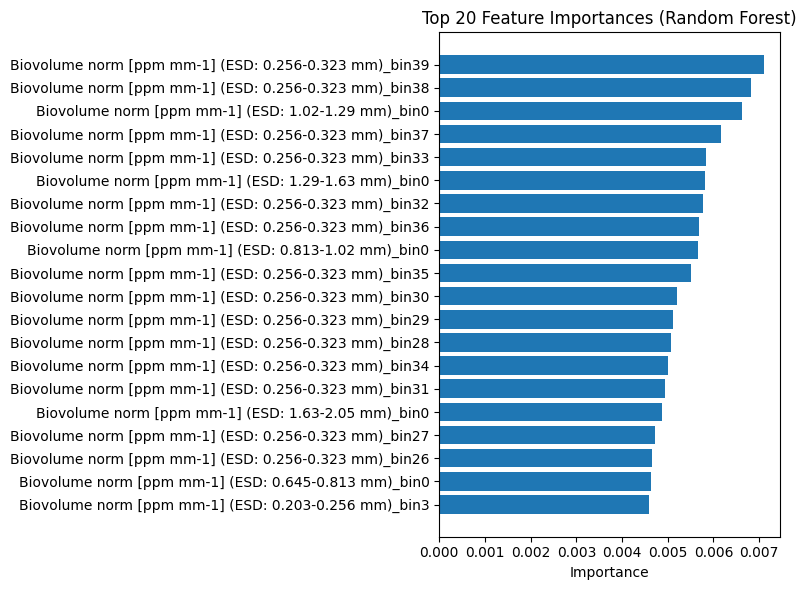

X_test_sample shape: (300, 680)
shap_values shape: (300, 680, 10)

=== SHAP Summary Plot for Class 0 ===


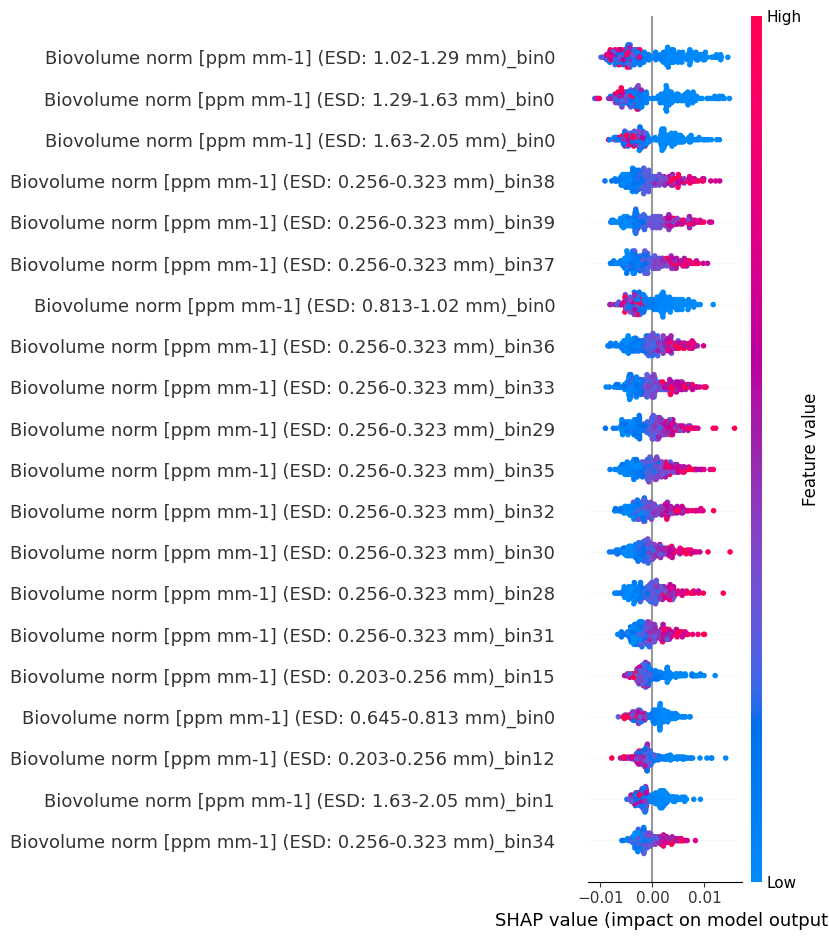


=== SHAP Summary Plot for Class 1 ===


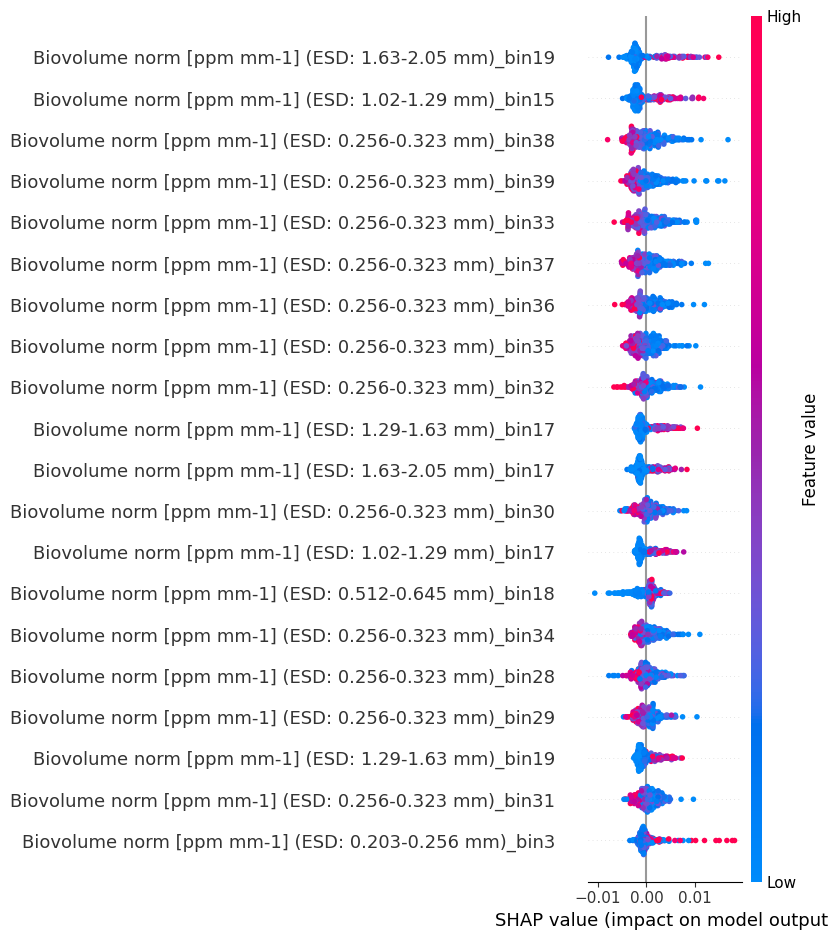


=== SHAP Summary Plot for Class 2 ===


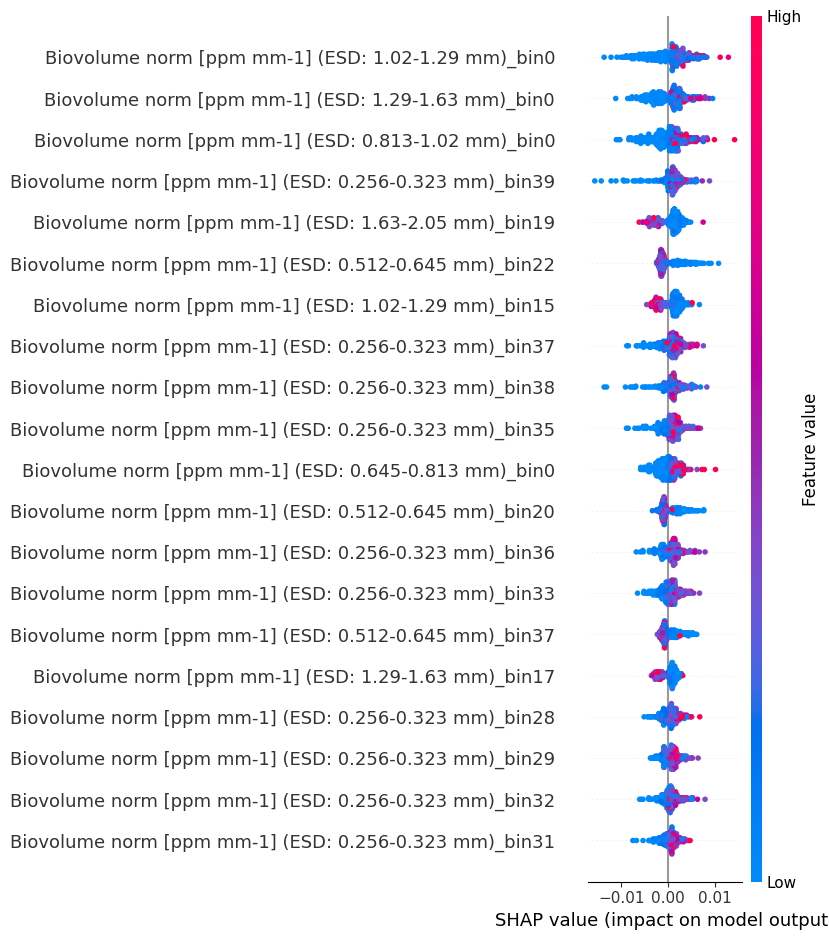


=== SHAP Summary Plot for Class 3 ===


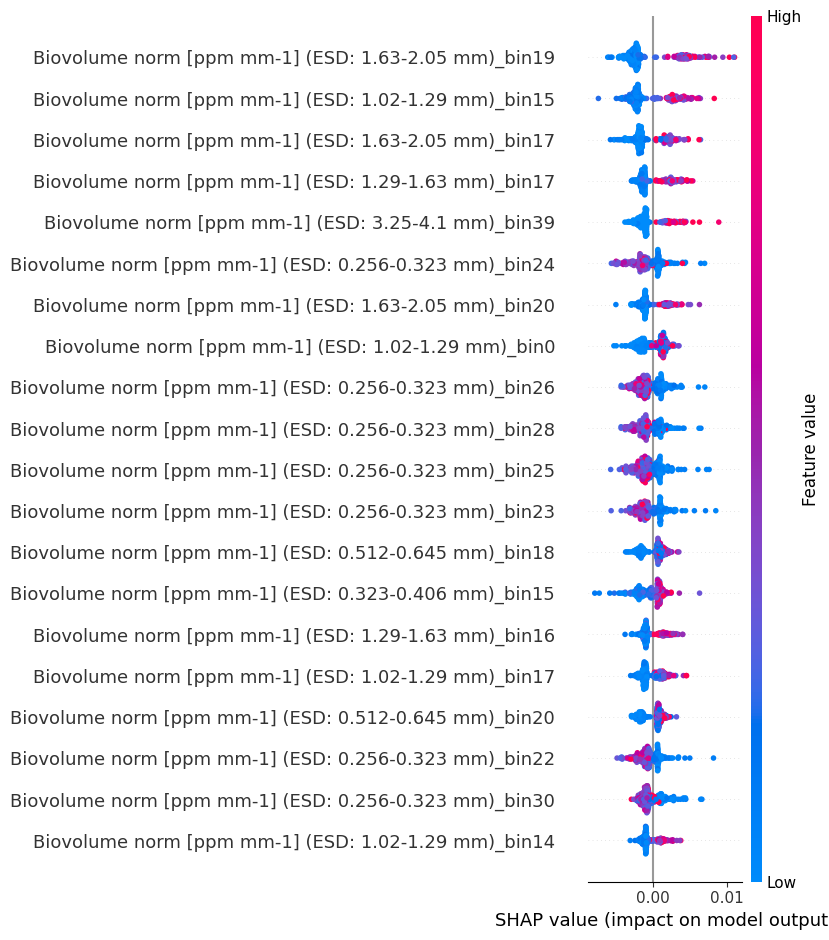


=== SHAP Summary Plot for Class 4 ===


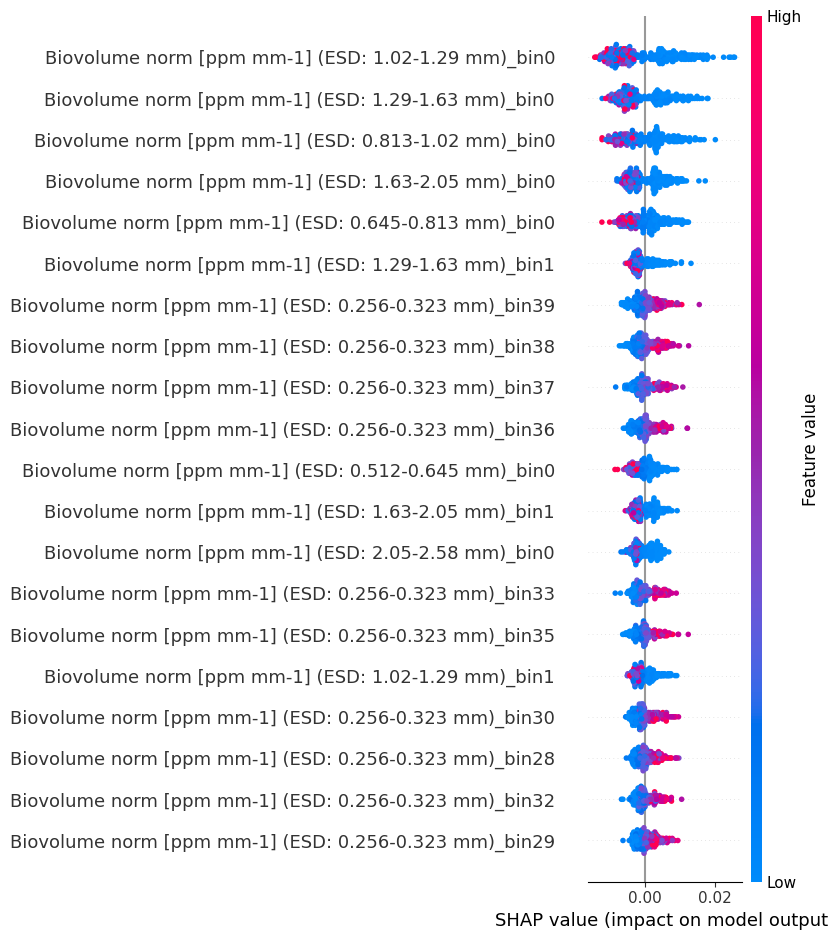


=== SHAP Summary Plot for Class 5 ===


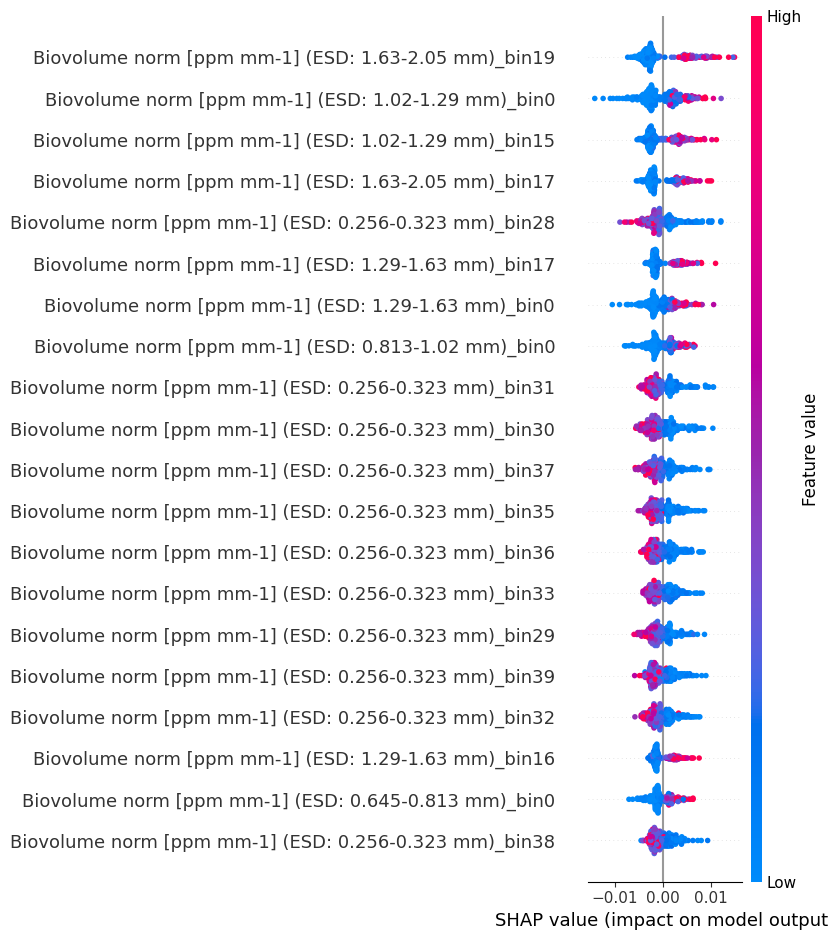


=== SHAP Summary Plot for Class 6 ===


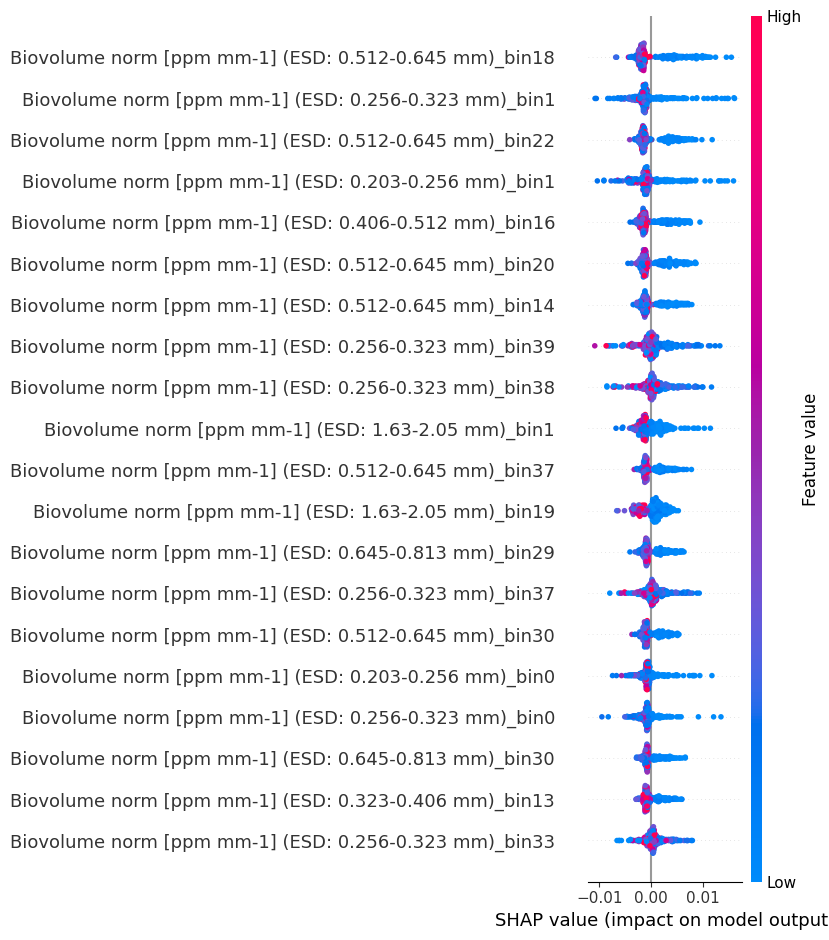


=== SHAP Summary Plot for Class 7 ===


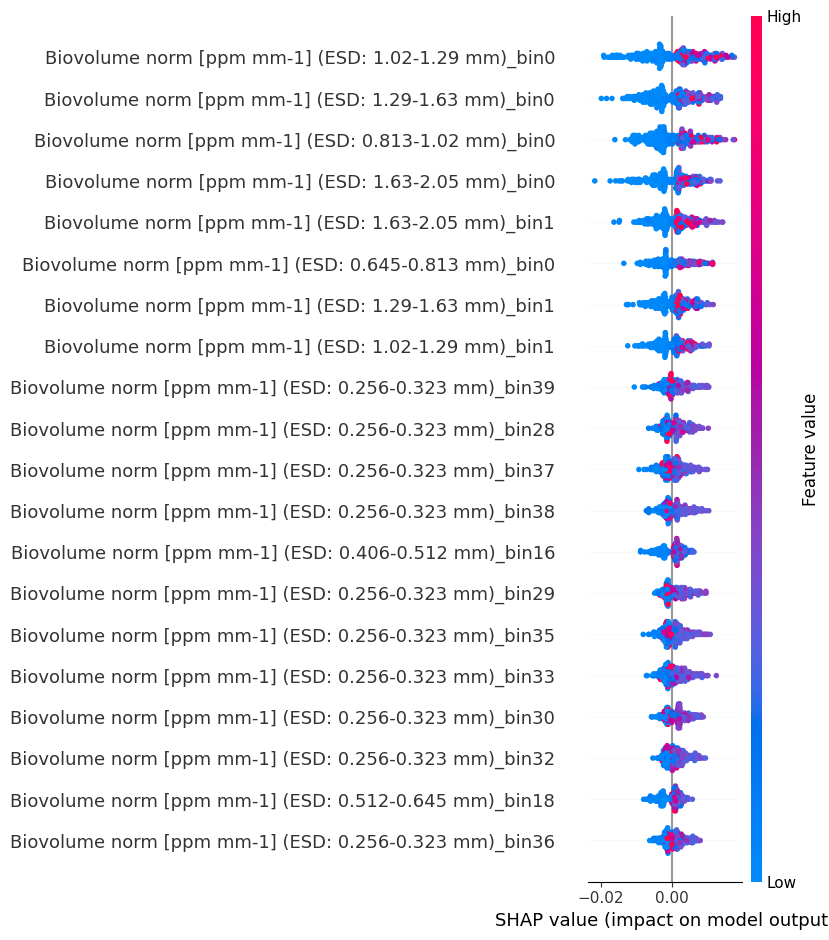


=== SHAP Summary Plot for Class 8 ===


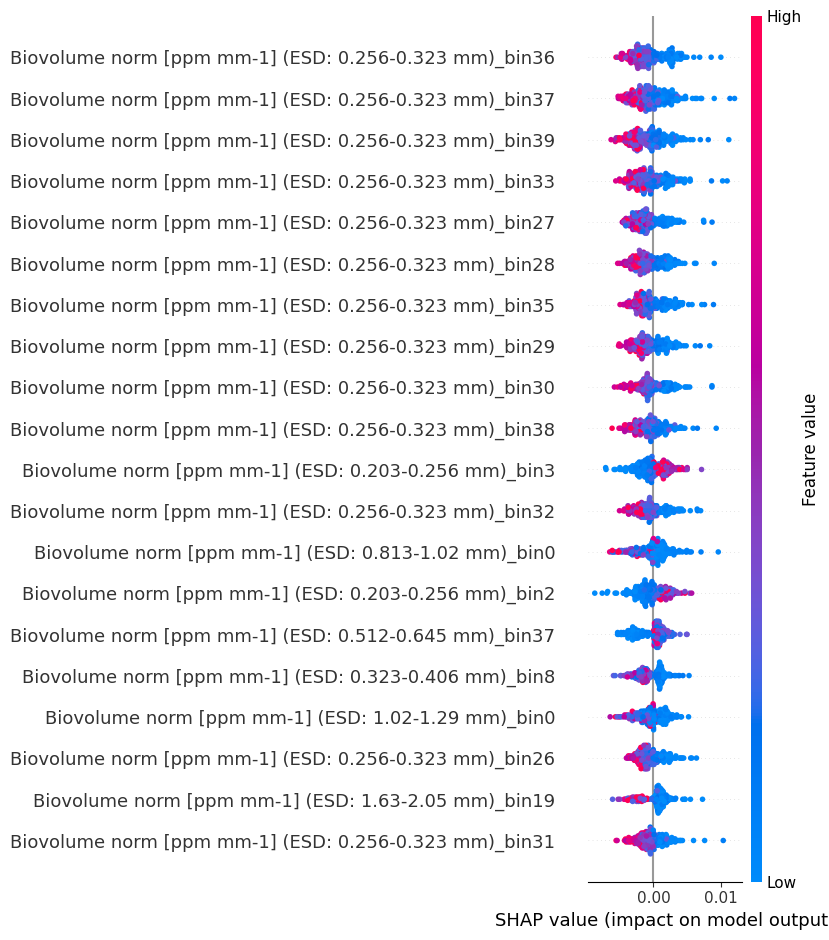


=== SHAP Summary Plot for Class 9 ===


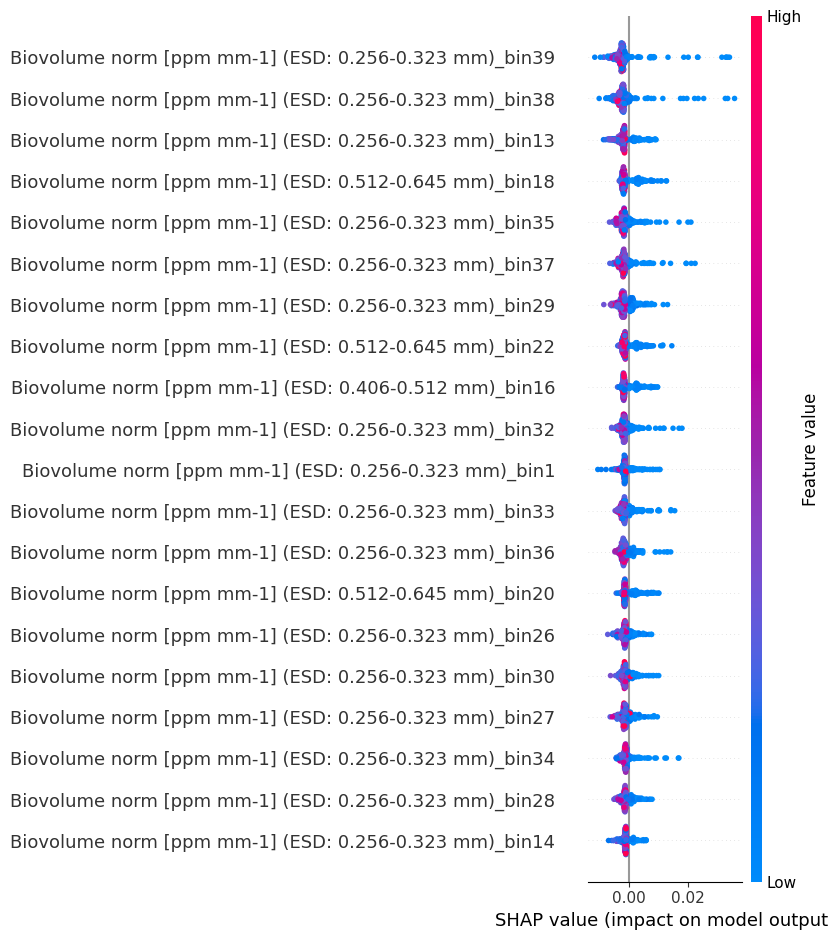


=== Top 20 Global SHAP Feature Importances ===
                                              Feature  MeanAbsSHAP
   Biovolume norm [ppm mm-1] (ESD: 1.02-1.29 mm)_bin0     0.003315
   Biovolume norm [ppm mm-1] (ESD: 1.29-1.63 mm)_bin0     0.002610
  Biovolume norm [ppm mm-1] (ESD: 0.813-1.02 mm)_bin0     0.002398
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin39     0.002340
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin38     0.002203
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin37     0.002155
  Biovolume norm [ppm mm-1] (ESD: 1.63-2.05 mm)_bin19     0.002125
   Biovolume norm [ppm mm-1] (ESD: 1.63-2.05 mm)_bin0     0.002068
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin33     0.001998
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin36     0.001961
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin35     0.001953
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin28     0.001868
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin29     0.001856
Biovolume norm

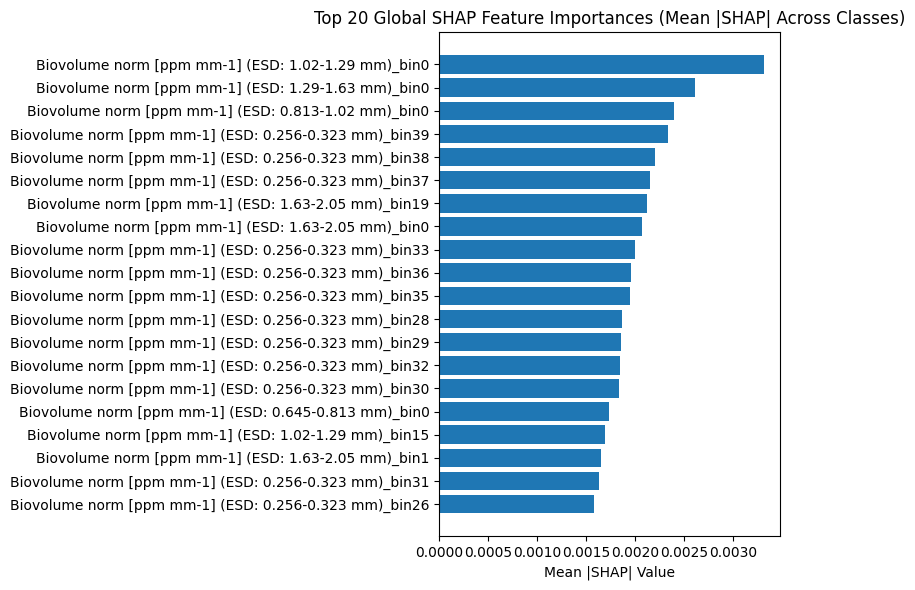

In [11]:
# -------------------------------
# Predictions on train and test data
# -------------------------------
y_pred_train = rf.predict(X_train_balanced)
y_pred_test  = rf.predict(X_test)

# -------------------------------
# Helper function to print metrics
# -------------------------------
def print_metrics(name, y_true, y_pred):
    print(f"\n=== {name} Metrics ===")
    print("Accuracy:          ", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy: ", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:          ", f1_score(y_true, y_pred, average='macro'))

# -------------------------------
# Train–test comparison
# -------------------------------
print_metrics("Train", y_train_balanced, y_pred_train)
print_metrics("Test",  y_test,          y_pred_test)

# -------------------------------
# Detailed evaluation (Test set only)
# -------------------------------
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_pred_test))

# -------------------------------
# Feature importance extraction
# -------------------------------
importances = rf.feature_importances_
feature_names = X_train_balanced.columns

feat_imp = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values(by="Importance", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Top 20 Most Important Features ===")
print(feat_imp.head(20).to_string(index=False))

# Optional: bar plot of top 20 feature importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["Feature"].head(top_n)[::-1],
         feat_imp["Importance"].head(top_n)[::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# =====================================================
# SHAP analysis (model explainability)
# =====================================================

#shap.initjs()

# Create explainer
explainer = shap.TreeExplainer(rf)

# Use a subset of the test data for speed
X_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)
shap_values = np.array(shap_values)   # expected shape: (n_samples, n_features, n_classes)

print("X_test_sample shape:", X_test_sample.shape)
print("shap_values shape:", shap_values.shape)

n_samples, n_features = X_test_sample.shape
_, sv_features, n_classes = shap_values.shape

assert sv_features == n_features, "Mismatch between SHAP feature dimension and X_test_sample"

# ---------------------------------------
# A: SHAP summary plot per class
# ---------------------------------------
for class_idx in range(n_classes):
    print(f"\n=== SHAP Summary Plot for Class {class_idx} ===")
    # shap_values for this class: (n_samples, n_features)
    sv_class = shap_values[:, :, class_idx]
    shap.summary_plot(sv_class, X_test_sample)

# ---------------------------------------
# B: Global SHAP importance across all classes
# ---------------------------------------
# Mean absolute SHAP over samples and classes -> (n_features,)
mean_abs_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))

shap_importance_df = (
    pd.DataFrame({
        "Feature": X_test_sample.columns,
        "MeanAbsSHAP": mean_abs_shap_per_feature
    })
    .sort_values("MeanAbsSHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Top 20 Global SHAP Feature Importances ===")
print(shap_importance_df.head(20).to_string(index=False))

# Optional bar plot of global SHAP importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(shap_importance_df["Feature"].head(top_n)[::-1],
         shap_importance_df["MeanAbsSHAP"].head(top_n)[::-1])
plt.title("Top 20 Global SHAP Feature Importances (Mean |SHAP| Across Classes)")
plt.xlabel("Mean |SHAP| Value")
plt.tight_layout()
plt.show()
    
